In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import logsumexp
import time

In [11]:
def generate_output_gap(n_obs, phi, sig, x0):

    standard_shocks = np.random.randn(n_obs-1)
    eps = sig**2 * standard_shocks

    x = np.zeros(n_obs)
    x[0] = x0
    
    for i in range(1, n_obs):
        x[i] = phi * x[i-1] + eps[i-1]

    return x

In [63]:
output_gap = generate_output_gap(100, 0.8, 10, 100)

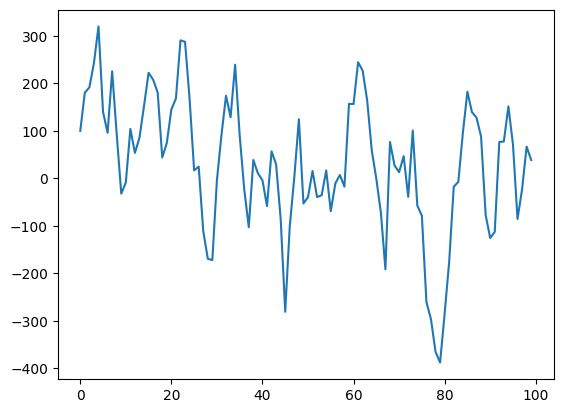

In [90]:
plt.plot(output_gap)
plt.show()

In [91]:
def generate_gdp(n_obs, alpha, tau, output_gap):

    standard_shocks = np.random.randn(n_obs-1)
    nu = tau**2 * standard_shocks

    y = np.zeros(n_obs-1)
    y[0] = np.nan
    
    for i in range(1,n_obs-1):
            y[i] = alpha * output_gap[i-1] + nu[i-1]

    return y

In [100]:
gdp = generate_gdp(100, 0.5, 2, output_gap)

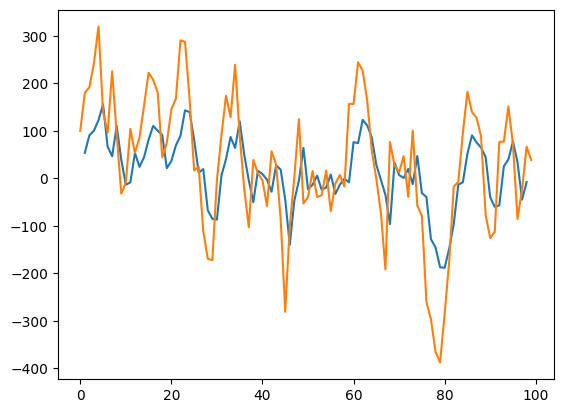

In [102]:
plt.plot(gdp,label='GDP')
plt.plot(output_gap,label='Output Gap')
plt.show()